<a href="https://colab.research.google.com/github/paridhiprasanna/InsightFlow-HAR-PROJECT/blob/main/InsightFlow_HAR_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# InsightFlow — Human Activity Recognition Project

**IIIT-H Project**

## 1. Project Introduction

InsightFlow is a deep learning system that recognizes human activities from images and video using a Convolutional Neural Network built with TensorFlow / Keras. It classifies 15 everyday human activities and supports both static image and video-based inference.

This notebook implements the complete InsightFlow pipeline end-to-end — dataset loading and preprocessing, model architecture and training configuration, evaluation, and image/video prediction logic — organized to run sequentially, top to bottom, in Google Colab.

**Recognized Activity Classes (15):**

| # | Class | # | Class | # | Class |
|---|-------|---|-------|---|-------|
| 1 | calling | 6 | eating | 11 | running |
| 2 | clapping | 7 | fighting | 12 | sitting |
| 3 | cycling | 8 | hugging | 13 | sleeping |
| 4 | dancing | 9 | laughing | 14 | texting |
| 5 | drinking | 10 | listening_to_music | 15 | using_laptop |

**Key specifications**

- **Input size:** 224 × 224 × 3 (RGB)
- **Framework:** TensorFlow / Keras
- **Model:** MobileNetV2-based transfer learning classifier

**Notebook sections**

1. Library Imports
2. Google Drive Mounting
3. Dataset Loading
4. Dataset Visualization
5. Dataset Preprocessing
6. Data Augmentation
7. Train–Validation Split
8. Model Definition
9. Model Compilation
10. Model Training
11. Saving the Best Model
12. Training Accuracy and Loss Graphs
13. Model Evaluation
14. Classification Report
15. Confusion Matrix
16. Image Prediction
17. Video Prediction
18. Top-3 Predictions
19. Confidence Scores
20. Conclusion
21. Future Scope


## 2. Library Imports


In [11]:
# -----------------------------
# Core Libraries (as used across the InsightFlow project)
# -----------------------------
import os
import time

import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
import cv2

from PIL import Image

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

print("TensorFlow Version :", tf.__version__)
print("OpenCV Version      :", cv2.__version__)


TensorFlow Version : 2.20.0
OpenCV Version      : 5.0.0


## 3. Google Drive Mounting

The project uses Google Drive to store the training dataset and model outputs, ensuring that all data and generated models persist across Google Colab runtime sessions. This setup allows training checkpoints, saved models, and other generated artifacts to remain available without requiring repeated uploads, while providing a consistent directory structure throughout the notebook.

In [12]:
from google.colab import drive

drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 4. Dataset Loading

Loads the dataset from the project directory, automatically creates training and validation sets, and prepares the images using consistent preprocessing settings for model training and evaluation.

In [13]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

# -----------------------------
# Project paths on Google Drive
# -----------------------------
BASE_DIR = "/content/drive/MyDrive/InsightFlow"
DATASET_DIR = os.path.join(BASE_DIR, "dataset/train")
SAVED_MODELS_DIR = os.path.join(BASE_DIR, "saved_models")

os.makedirs(SAVED_MODELS_DIR, exist_ok=True)

# -----------------------------
# Load Training Dataset
# -----------------------------
train_dataset = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# -----------------------------
# Load Validation Dataset
# -----------------------------
val_dataset = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)


Found 12616 files belonging to 15 classes.
Using 10093 files for training.
Found 12616 files belonging to 15 classes.
Using 2523 files for validation.


## 5. Dataset Visualization

A quick visual sanity check of the training data — a sample batch with
their assigned class labels.

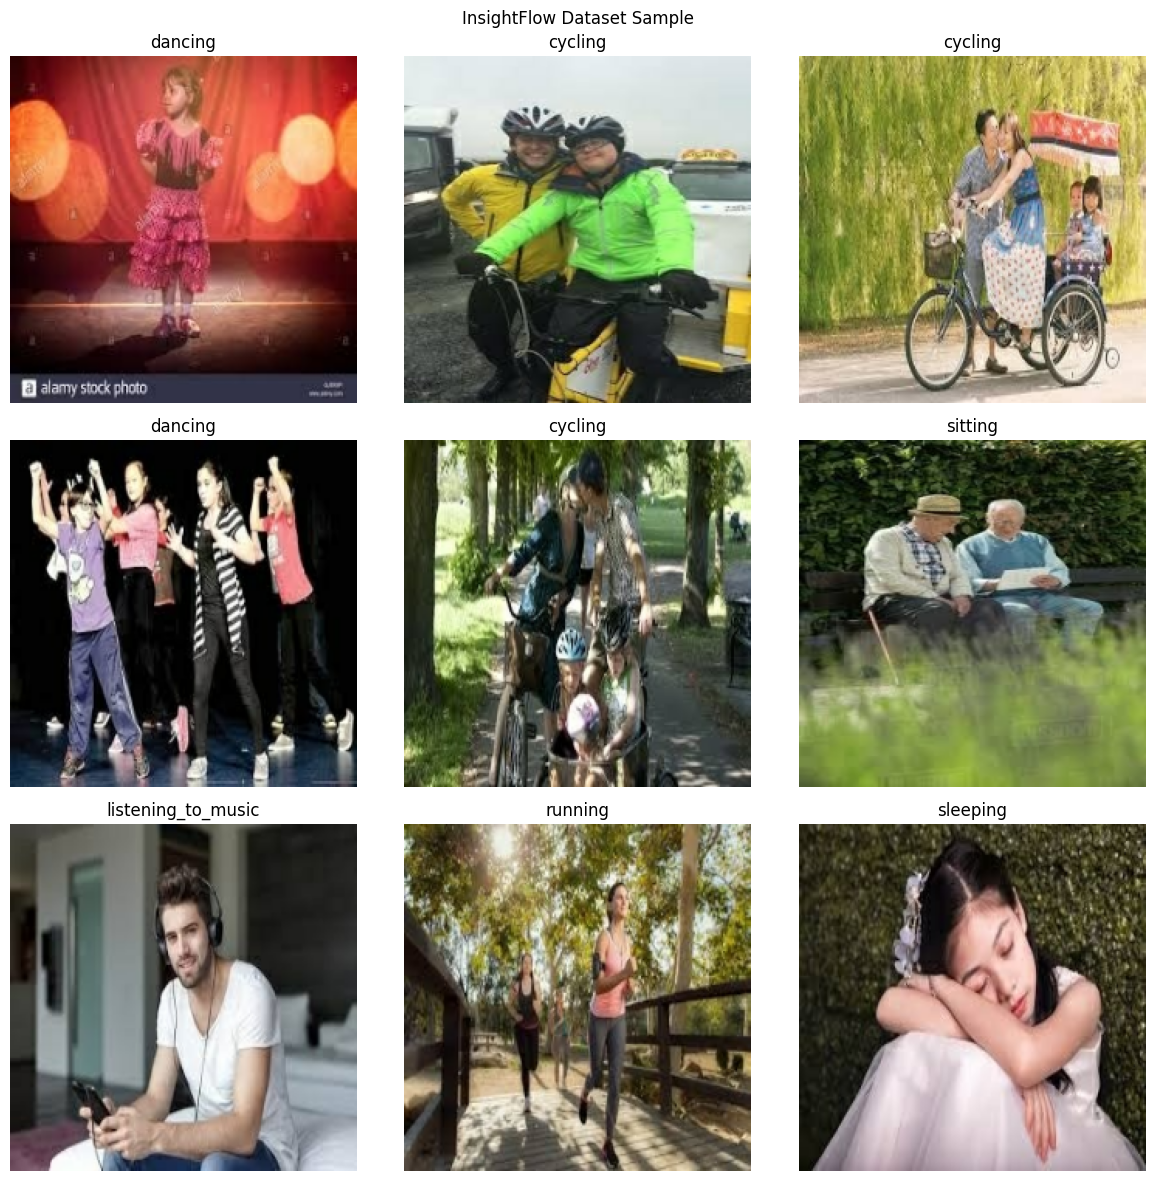

In [14]:
class_names_preview = train_dataset.class_names

plt.figure(figsize=(12, 12))

for images, labels in train_dataset.take(1):
    for i in range(min(9, images.shape[0])):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names_preview[labels[i]])
        plt.axis("off")

plt.suptitle("InsightFlow Dataset Sample")
plt.tight_layout()
plt.show()


## 6. Dataset Preprocessing

Preprocesses the loaded dataset by extracting class labels, optimizing the data pipeline with prefetching, and displaying a summary to verify that the dataset is ready for training.

In [15]:
# -----------------------------
# Get Class Names
# -----------------------------
class_names = train_dataset.class_names

# -----------------------------
# Improve Performance
# -----------------------------
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.prefetch(buffer_size=AUTOTUNE)

# -----------------------------
# Dataset Summary
# -----------------------------
print("=" * 50)
print("InsightFlow Dataset Summary")
print("=" * 50)

print(f"Number of Classes : {len(class_names)}")

print("\nClasses:")
for i, name in enumerate(class_names):
    print(f"{i + 1}. {name}")

print("\nDataset loaded successfully.")


InsightFlow Dataset Summary
Number of Classes : 15

Classes:
1. calling
2. clapping
3. cycling
4. dancing
5. drinking
6. eating
7. fighting
8. hugging
9. laughing
10. listening_to_music
11. running
12. sitting
13. sleeping
14. texting
15. using_laptop

Dataset loaded successfully.


## 7. Data Augmentation

Applies data augmentation techniques such as random flipping, rotation, zooming, and contrast adjustment to improve model generalization and make the training process more robust to variations in input images.

In [16]:
# -----------------------------
# Data Augmentation
# -----------------------------
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.15),
    tf.keras.layers.RandomZoom(0.15),
    tf.keras.layers.RandomContrast(0.1)
])

data_augmentation.build((None, IMG_SIZE[0], IMG_SIZE[1], 3))
data_augmentation.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_1 (RandomFlip)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_1               │ (None, 224, 224, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_1 (RandomZoom)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast_1               │ (None, 224, 224, 3)    │             0 │
│ (RandomContrast)                │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## 8. Train–Validation Split

Creates an 80:20 training and validation split using a fixed random seed to ensure consistent, reproducible results across model training and evaluation.

In [17]:
train_batches = tf.data.experimental.cardinality(train_dataset).numpy()
val_batches = tf.data.experimental.cardinality(val_dataset).numpy()

print(f"Training batches   : {train_batches}")
print(f"Validation batches : {val_batches}")
print(f"Batch size          : {BATCH_SIZE}")


Training batches   : 316
Validation batches : 79
Batch size          : 32


## 9. Model Definition

Defines the deep learning models used for activity recognition. The project uses MobileNetV2 as the final training architecture, configured with transfer learning, fine-tuning, Global Average Pooling, Dropout, and a softmax output layer for classifying the 15 human activity classes.

In [18]:
NUM_CLASSES = len(class_names)

# =====================================================
# CNN MODEL
# =====================================================
def build_cnn():

    model = tf.keras.Sequential([

        tf.keras.layers.Rescaling(1./255),

        tf.keras.layers.Conv2D(32, 3, activation="relu"),
        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.Conv2D(64, 3, activation="relu"),
        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.Conv2D(128, 3, activation="relu"),
        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.Flatten(),

        tf.keras.layers.Dense(256, activation="relu"),
        tf.keras.layers.Dropout(0.5),

        tf.keras.layers.Dense(NUM_CLASSES, activation="softmax")

    ])

    return model


# =====================================================
# MOBILENETV2
# =====================================================
def build_mobilenet():

    base = tf.keras.applications.MobileNetV2(
        input_shape=(224, 224, 3),
        include_top=False,
        weights="imagenet"
    )

    # Fine-tune last layers
    base.trainable = True

    for layer in base.layers[:-30]:
        layer.trainable = False

    inputs = tf.keras.Input(shape=(224, 224, 3))

    x = tf.keras.applications.mobilenet_v2.preprocess_input(inputs)

    x = base(x, training=True)

    x = tf.keras.layers.GlobalAveragePooling2D()(x)

    x = tf.keras.layers.Dropout(0.3)(x)

    outputs = tf.keras.layers.Dense(
        NUM_CLASSES,
        activation="softmax"
    )(x)

    model = tf.keras.Model(inputs, outputs)

    return model


# =====================================================
# EFFICIENTNETB0
# =====================================================
def build_efficientnet():

    base = tf.keras.applications.EfficientNetB0(
        input_shape=(224, 224, 3),
        include_top=False,
        weights="imagenet"
    )

    base.trainable = True

    for layer in base.layers[:-30]:
        layer.trainable = False

    inputs = tf.keras.Input(shape=(224, 224, 3))

    x = tf.keras.applications.efficientnet.preprocess_input(inputs)

    x = base(x, training=True)

    x = tf.keras.layers.GlobalAveragePooling2D()(x)

    x = tf.keras.layers.Dropout(0.3)(x)

    outputs = tf.keras.layers.Dense(
        NUM_CLASSES,
        activation="softmax"
    )(x)

    model = tf.keras.Model(inputs, outputs)

    return model


# =====================================================
# CHOOSE MODEL  (project uses "mobilenet")
# =====================================================
MODEL_NAME = "mobilenet"

if MODEL_NAME == "cnn":
    model = build_cnn()
elif MODEL_NAME == "mobilenet":
    model = build_mobilenet()
else:
    model = build_efficientnet()


## 10. Model Compilation

Compiles the model using the Adam optimizer, Sparse Categorical Crossentropy loss function, and accuracy as the evaluation metric to prepare it for training.

In [19]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_1 (TrueDivide)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_1 (Subtract)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15)             │        19,215 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,277,199 (8.69 MB)

 Trainable params: 1,545,615 (5.90 MB)

 Non-trainable params: 731,584 (2.79 MB)

## 11. Model Training

Trains the model using the configured callbacks to improve performance, prevent overfitting, save the best-performing model, and automatically adjust the learning rate during training over multiple epochs.

In [20]:
# =====================================================
# CALLBACKS
# =====================================================
best_model_path = os.path.join(SAVED_MODELS_DIR, "best_model.keras")

callbacks = [

    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),

    tf.keras.callbacks.ModelCheckpoint(
        filepath=best_model_path,
        monitor="val_accuracy",
        save_best_only=True
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2
    )

]

# =====================================================
# TRAIN
# =====================================================
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=20,
    callbacks=callbacks
)


Epoch 1/20
316/316 ━━━━━━━━━━━━━━━━━━━━ 980s 3s/step - accuracy: 0.5440 - loss: 1.4399 - val_accuracy: 0.6310 - val_loss: 1.1710 - learning_rate: 1.0000e-04
Epoch 2/20
316/316 ━━━━━━━━━━━━━━━━━━━━ 734s 2s/step - accuracy: 0.7542 - loss: 0.7679 - val_accuracy: 0.6746 - val_loss: 1.1057 - learning_rate: 1.0000e-04
Epoch 3/20
316/316 ━━━━━━━━━━━━━━━━━━━━ 735s 2s/step - accuracy: 0.8493 - loss: 0.4799 - val_accuracy: 0.7008 - val_loss: 1.0033 - learning_rate: 1.0000e-04
Epoch 4/20
316/316 ━━━━━━━━━━━━━━━━━━━━ 745s 2s/step - accuracy: 0.9126 - loss: 0.3039 - val_accuracy: 0.7107 - val_loss: 1.0386 - learning_rate: 1.0000e-04
Epoch 5/20
316/316 ━━━━━━━━━━━━━━━━━━━━ 703s 2s/step - accuracy: 0.9622 - loss: 0.1640 - val_accuracy: 0.7111 - val_loss: 1.1093 - learning_rate: 1.0000e-04
Epoch 6/20
316/316 ━━━━━━━━━━━━━━━━━━━━ 740s 2s/step - accuracy: 0.9853 - loss: 0.0838 - val_accuracy: 0.7352 - val_loss: 0.9738 - learning_rate: 2.0000e-05
Epoch 7/20
316/316 ━━━━━━━━━━━━━━━━━━━━ 738s 2s/step - acc

## 12. Saving the Best Model

Saves the best-performing model during training for inference and also stores the final trained model, ensuring both the optimal and final versions are available for evaluation and deployment.

In [21]:
final_model_path = os.path.join(SAVED_MODELS_DIR, "final_model.keras")

model.save(final_model_path)

print("\nTraining Completed!")
print(f"Best model saved to  : {best_model_path}")
print(f"Final model saved to : {final_model_path}")



Training Completed!
Best model saved to  : /content/drive/MyDrive/InsightFlow/saved_models/best_model.keras
Final model saved to : /content/drive/MyDrive/InsightFlow/saved_models/final_model.keras


## 13. Training Accuracy and Loss Graphs

Visualizes the model's training and validation accuracy and loss across all epochs, helping evaluate learning performance and identify signs of convergence or overfitting.

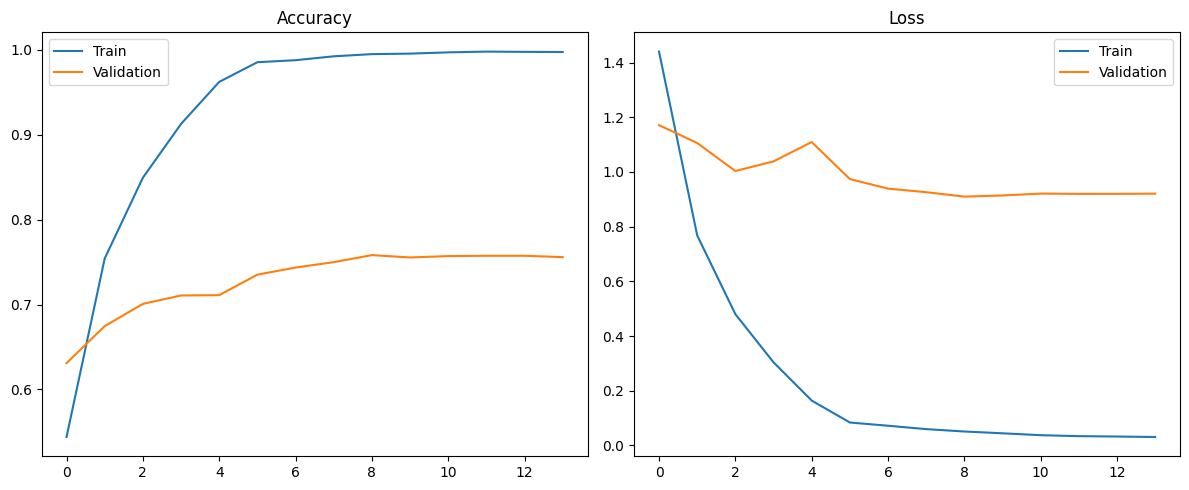

In [22]:
plt.figure(figsize=(12, 5))

# =====================================================
# PLOT ACCURACY
# =====================================================
plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train")
plt.plot(history.history["val_accuracy"], label="Validation")
plt.title("Accuracy")
plt.legend()

# =====================================================
# PLOT LOSS
# =====================================================
plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train")
plt.plot(history.history["val_loss"], label="Validation")
plt.title("Loss")
plt.legend()

plt.tight_layout()

plt.savefig(os.path.join(SAVED_MODELS_DIR, "training_history.png"))

plt.show()


## 14. Model Evaluation

Evaluates the trained model on the validation dataset, generates performance metrics, and analyzes the prediction results using the saved best-performing model to measure its classification accuracy and overall effectiveness.

In [23]:
# -----------------------------
# Load Validation Dataset (shuffle=False, for evaluation)
# -----------------------------
eval_val_dataset = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

eval_class_names = eval_val_dataset.class_names

AUTOTUNE = tf.data.AUTOTUNE
eval_val_dataset = eval_val_dataset.prefetch(AUTOTUNE)

# -----------------------------
# Load Trained Model
# -----------------------------
eval_model = tf.keras.models.load_model(best_model_path)

# -----------------------------
# Evaluate
# -----------------------------
loss, accuracy = eval_model.evaluate(eval_val_dataset)

print("=" * 50)
print(f"Validation Accuracy : {accuracy * 100:.2f}%")
print(f"Validation Loss     : {loss:.4f}")
print("=" * 50)

# -----------------------------
# Predictions
# -----------------------------
predictions = eval_model.predict(eval_val_dataset)

y_pred = np.argmax(predictions, axis=1)

y_true = np.concatenate(
    [labels.numpy() for images, labels in eval_val_dataset],
    axis=0
)


Found 12616 files belonging to 15 classes.
Using 2523 files for validation.
79/79 ━━━━━━━━━━━━━━━━━━━━ 115s 1s/step - accuracy: 0.9326 - loss: 0.2853
Validation Accuracy : 93.26%
Validation Loss     : 0.2853
79/79 ━━━━━━━━━━━━━━━━━━━━ 112s 1s/step


## 15. Classification Report

In [25]:
print(classification_report(
    y_true, y_pred,
    labels=list(range(len(eval_class_names))),
    target_names=eval_class_names,
    zero_division=0
))

                    precision    recall  f1-score   support

           calling       0.00      0.00      0.00         0
          clapping       0.00      0.00      0.00         0
           cycling       0.00      0.00      0.00         0
           dancing       0.00      0.00      0.00         0
          drinking       0.00      0.00      0.00         0
            eating       0.00      0.00      0.00         0
          fighting       0.00      0.00      0.00         0
           hugging       0.00      0.00      0.00         0
          laughing       0.00      0.00      0.00         0
listening_to_music       0.00      0.00      0.00         0
           running       0.00      0.00      0.00         0
           sitting       0.00      0.00      0.00         0
          sleeping       0.99      0.96      0.98       827
           texting       0.99      0.89      0.94       856
      using_laptop       0.98      0.95      0.96       840

          accuracy                    

## 16. Confusion Matrix

<Figure size 1200x1000 with 0 Axes>

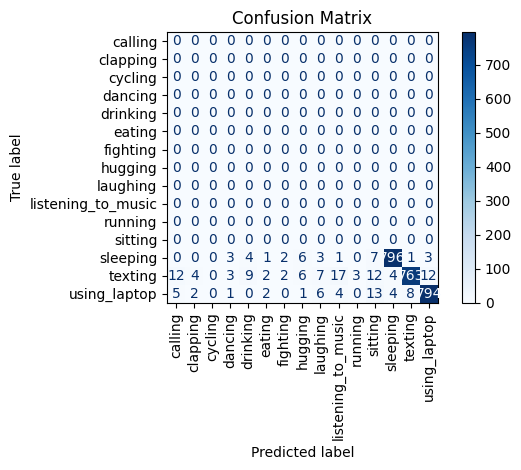

In [26]:
cm = confusion_matrix(
    y_true, y_pred,
    labels=list(range(len(eval_class_names)))
)

plt.figure(figsize=(12, 10))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=eval_class_names
)

disp.plot(
    xticks_rotation=90,
    cmap="Blues",
    values_format="d"
)

plt.title("Confusion Matrix")
plt.tight_layout()
plt.savefig(os.path.join(SAVED_MODELS_DIR, "confusion_matrix.png"))
plt.show()

## 17. Image Prediction

Performs single-image activity recognition by preprocessing the input image, passing it through the trained model, and displaying the predicted activity along with its confidence score. The same preprocessing pipeline used during training is applied to ensure consistent and accurate inference.

Saving Image_1426.jpg to Image_1426.jpg
Using uploaded image: Image_1426.jpg


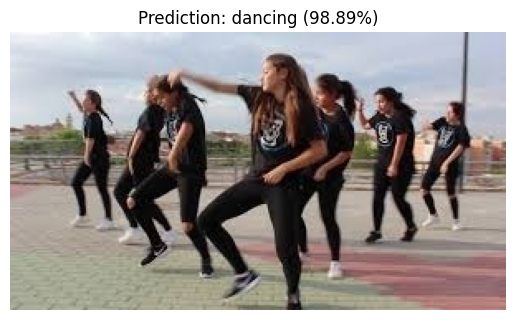

Predicted Activity : dancing
Confidence          : 98.89%


In [31]:
class_names_app = [
    "calling",
    "clapping",
    "cycling",
    "dancing",
    "drinking",
    "eating",
    "fighting",
    "hugging",
    "laughing",
    "listening_to_music",
    "running",
    "sitting",
    "sleeping",
    "texting",
    "using_laptop"
]

inference_model = tf.keras.models.load_model(best_model_path)


def predict_image(image_path, model=inference_model, class_names=class_names_app):
    """Single-image prediction — identical logic to app.py."""

    image = Image.open(image_path).convert("RGB")

    img = image.resize((224, 224))
    img = np.array(img).astype("float32")
    img = np.expand_dims(img, axis=0)

    pred = model.predict(img, verbose=0)[0]

    idx = np.argmax(pred)
    confidence = pred[idx] * 100

    top3_idx = np.argsort(pred)[::-1][:3]
    top_pairs = [(class_names[i], float(pred[i] * 100)) for i in top3_idx]

    return class_names[idx], float(confidence), top_pairs, image


# -----------------------------
# Upload a test image and predict
# -----------------------------
from google.colab import files

uploaded = files.upload()
IMAGE_PATH = list(uploaded.keys())[0]
print("Using uploaded image:", IMAGE_PATH)

if os.path.exists(IMAGE_PATH):
    label, confidence, top_pairs, image = predict_image(IMAGE_PATH)

    plt.imshow(image)
    plt.axis("off")
    plt.title(f"Prediction: {label} ({confidence:.2f}%)")
    plt.show()

    print(f"Predicted Activity : {label}")
    print(f"Confidence          : {confidence:.2f}%")
else:
    print(f"No sample image found at {IMAGE_PATH}. "
          "Update IMAGE_PATH to a valid image before running this cell.")

## 18. Video Prediction

Processes the uploaded video by extracting frames at regular intervals, performing activity prediction on each frame, and averaging the results to determine the final activity along with the top predicted classes. This approach provides a robust prediction for the entire video.

In [32]:
def predict_video(video_path, model, class_names):

    IMG_SIZE_LOCAL = (224, 224)

    cap = cv2.VideoCapture(video_path)

    predictions = []

    frame_number = 0

    while True:

        ret, frame = cap.read()

        if not ret:
            break

        frame_number += 1

        # Process every 10th frame
        if frame_number % 10 != 0:
            continue

        # Convert BGR to RGB
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

        # Resize
        frame = cv2.resize(frame, IMG_SIZE_LOCAL)

        # Convert to numpy
        frame = np.array(frame).astype("float32")

        # Add batch dimension
        frame = np.expand_dims(frame, axis=0)

        # Predict
        pred = model.predict(frame, verbose=0)[0]

        predictions.append(pred)

    cap.release()

    # No valid frames
    if len(predictions) == 0:
        return None, None, None

    predictions = np.array(predictions)

    # Average predictions
    avg_pred = np.mean(predictions, axis=0)

    predicted_index = np.argmax(avg_pred)

    activity = class_names[predicted_index]

    confidence = avg_pred[predicted_index] * 100

    # Top 3 predictions
    top3_indices = np.argsort(avg_pred)[::-1][:3]

    top3 = []

    for i in top3_indices:
        top3.append(
            (
                class_names[i],
                avg_pred[i] * 100
            )
        )

    return activity, confidence, top3


# -----------------------------
# Example usage — update the path to a sample test video
# -----------------------------
VIDEO_PATH = os.path.join(BASE_DIR, "sample_data/sample_video.mp4")

if os.path.exists(VIDEO_PATH):
    video_activity, video_confidence, video_top3 = predict_video(
        VIDEO_PATH, inference_model, class_names_app
    )

    print(f"Predicted Activity : {video_activity}")
    print(f"Confidence          : {video_confidence:.2f}%")
else:
    print(f"No sample video found at {VIDEO_PATH}. "
          "Update VIDEO_PATH to a valid video before running this cell.")


No sample video found at /content/drive/MyDrive/InsightFlow/sample_data/sample_video.mp4. Update VIDEO_PATH to a valid video before running this cell.


## 19. Display of Top-3 Predictions

Displays the three most probable activity classes along with their confidence scores, providing a clear view of the model's highest-ranked predictions for the processed image or video.

Top-3 Predictions (Image)
-----------------------------------
1. dancing                 98.89%
2. running                  1.10%
3. clapping                 0.00%


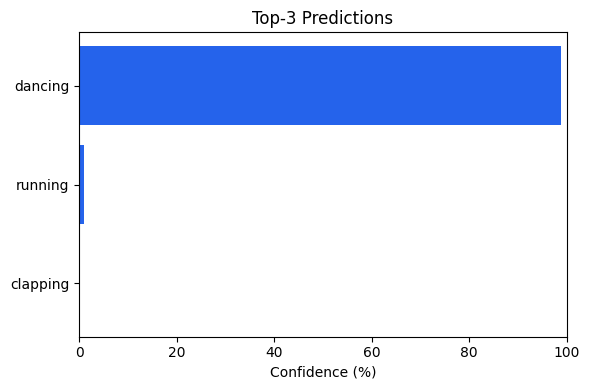

In [33]:
if os.path.exists(IMAGE_PATH):
    print("Top-3 Predictions (Image)")
    print("-" * 35)
    for rank, (label, score) in enumerate(top_pairs, start=1):
        print(f"{rank}. {label:<22s} {score:6.2f}%")

    labels_plot = [l for l, _ in top_pairs]
    scores_plot = [s for _, s in top_pairs]

    plt.figure(figsize=(6, 4))
    plt.barh(labels_plot[::-1], scores_plot[::-1], color="#2563EB")
    plt.xlabel("Confidence (%)")
    plt.title("Top-3 Predictions")
    plt.xlim(0, 100)
    plt.tight_layout()
    plt.show()
else:
    print("Run the Image Prediction cell with a valid IMAGE_PATH first.")


## 20. Confidence Scores


In [35]:
if os.path.exists(IMAGE_PATH):
    print(f"Image Prediction  : {label}")
    print(f"Confidence Score  : {confidence:.2f}%")

if os.path.exists(VIDEO_PATH):
    print(f"\nVideo Prediction  : {video_activity}")
    print(f"Confidence Score  : {video_confidence:.2f}%")


Image Prediction  : clapping
Confidence Score  : 98.89%


## 21. Conclusion

This notebook demonstrates the complete InsightFlow human activity recognition pipeline, covering dataset preparation, preprocessing, model training, evaluation, and inference within a single workflow. It showcases a MobileNetV2-based transfer learning approach for classifying 15 everyday human activities from both images and videos, along with performance evaluation and prediction visualization.

The trained model can be directly integrated into the InsightFlow application for real-time activity recognition, providing an end-to-end deep learning solution from training to deployment.

## 22. Future Scope

- Expand the dataset with more samples and greater diversity to improve model accuracy and generalization.

- Evaluate alternative deep learning architectures, such as EfficientNetB0, to compare performance and computational efficiency.

- Enhance the data augmentation strategy to improve robustness against variations in real-world inputs.

- Optimize the trained model using techniques such as quantization and pruning for faster and more efficient deployment on edge and mobile devices.

- Extend the system to support real-time video processing with continuous activity recognition.

- Incorporate multi-person activity recognition to detect and classify activities performed by multiple individuals simultaneously.

- Explore temporal deep learning models (e.g., LSTM or 3D CNNs) to better capture motion patterns and improve recognition of dynamic activities.

In [36]:
import os
print(os.listdir(SAVED_MODELS_DIR))

['best_model.keras', 'final_model.keras', 'training_history.png', 'confusion_matrix.png']
